# Project: Tux the Linux Penguin

Multi-color, support-free figurine (~78 mm tall). Three print plates split by filament color:
- **Black**: body shell + head + wings
- **White**: belly patch + eye whites (with pupil recesses)
- **Yellow/Orange**: beak + two feet

Assembly: press-fit into matching sockets. Every piece prints flat-side-down, no supports.

## 1. The need

A desktop figurine of Tux, the Linux mascot. Must be printable on a single-material FDM printer
one color at a time, then snapped together. Minimal support structures.
Color segmentation means each plate = one filament spool.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parents[1] / 'src'))
from agentic_cad.runner import run
from agentic_cad.study import run_study
from agentic_cad.nb import show_run, show_annotations

PROFILE = Path.cwd().parents[1] / 'profiles' / 'elegoo_cc2_pla.json'
MODEL = Path.cwd() / 'model.py'
OUT = Path.cwd() / 'outputs'

## 2. Build and verify

Runs the model through evidence gates (B-rep, mesh integrity, clearance) and renders it.

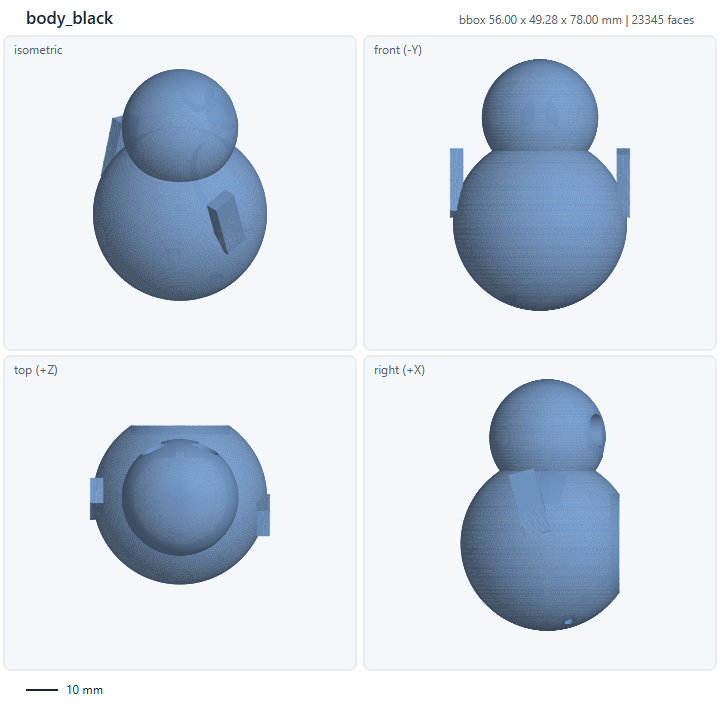

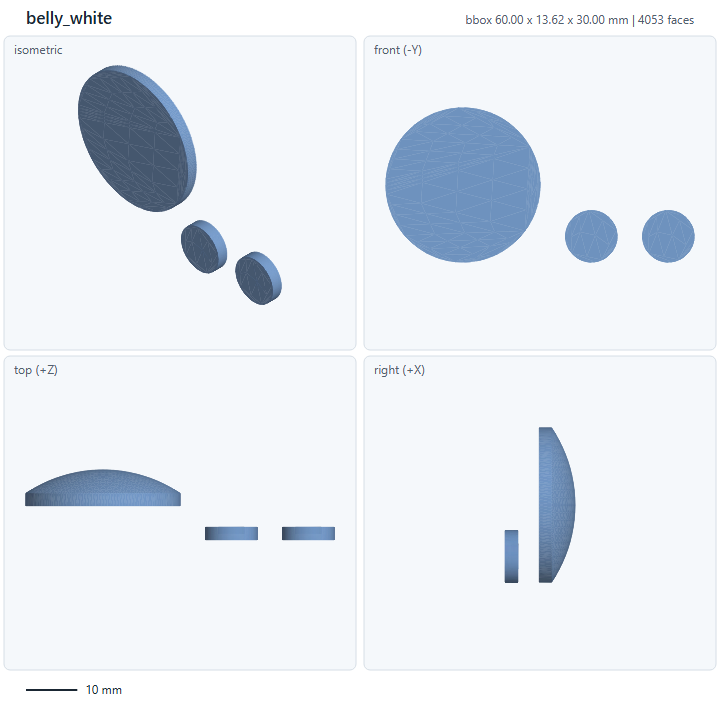

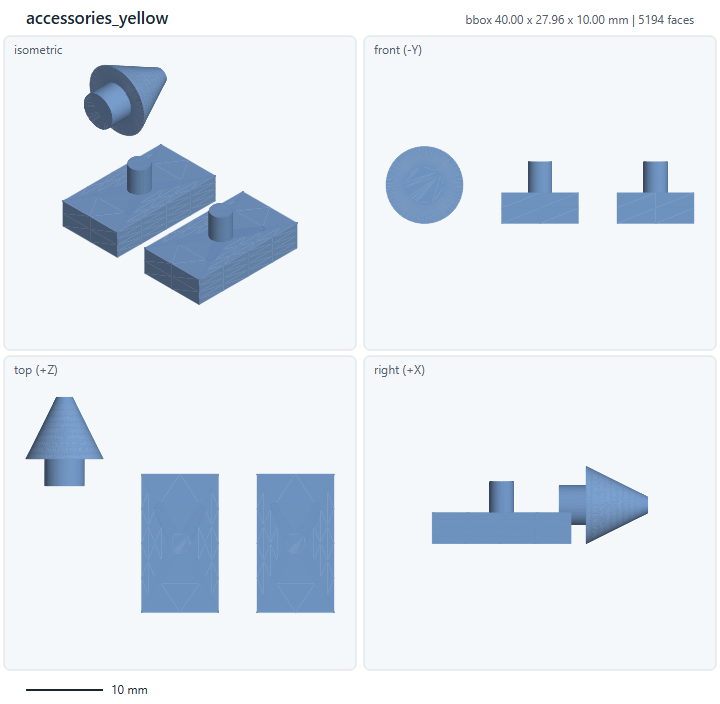

In [2]:
report_path, report = run(MODEL, PROFILE, OUT, enable_slicer=False, enable_freecad=False, enable_raster=True)
show_run(report)

## 3. Annotate what to change

Open the `annotate:` file shown above in a browser, pin comments on the views,
export `annotations.json` into this folder, then run the next cell.

In [3]:
# pins = show_annotations(Path.cwd() / 'annotations.json')

## 4. Parameter sweep (optional)

Uncomment to explore different proportions.

In [4]:
# _, study = run_study(MODEL, PROFILE, OUT / 'studies',
#     {'belly_radius_mm': [12.0, 15.0, 18.0]}, minimize='total_volume_mm3')
# print(study['recommended'])

## 5. Release

Full gates: FreeCAD STEP round-trip + real slicer. Print files land in `outputs/tux_penguin/`.

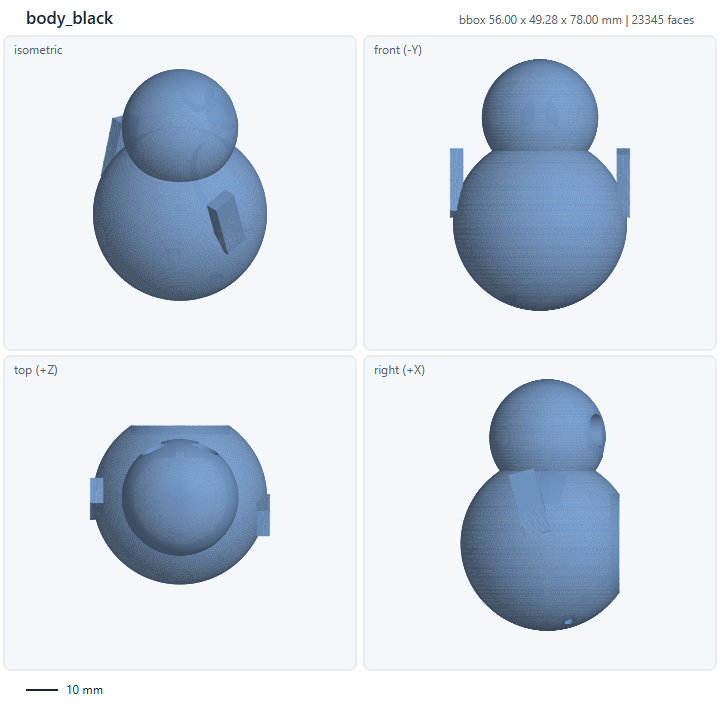

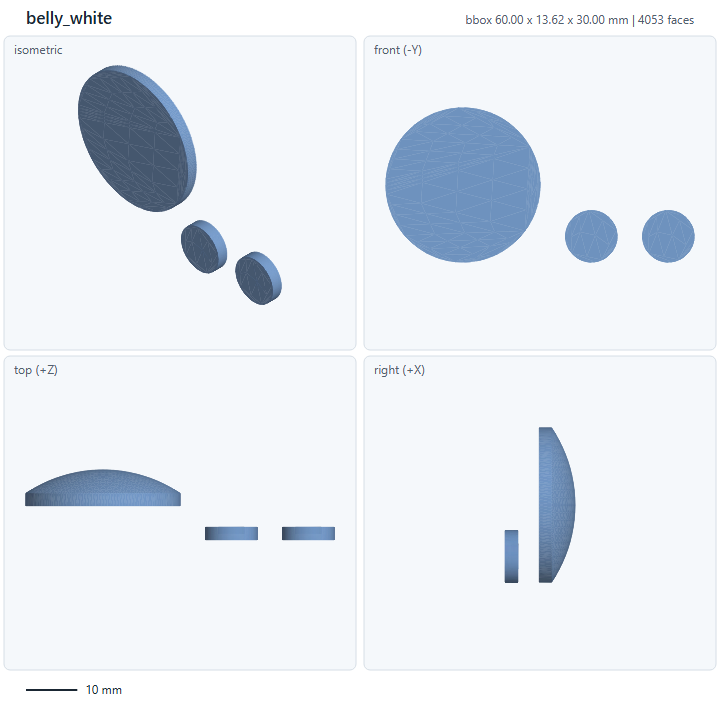

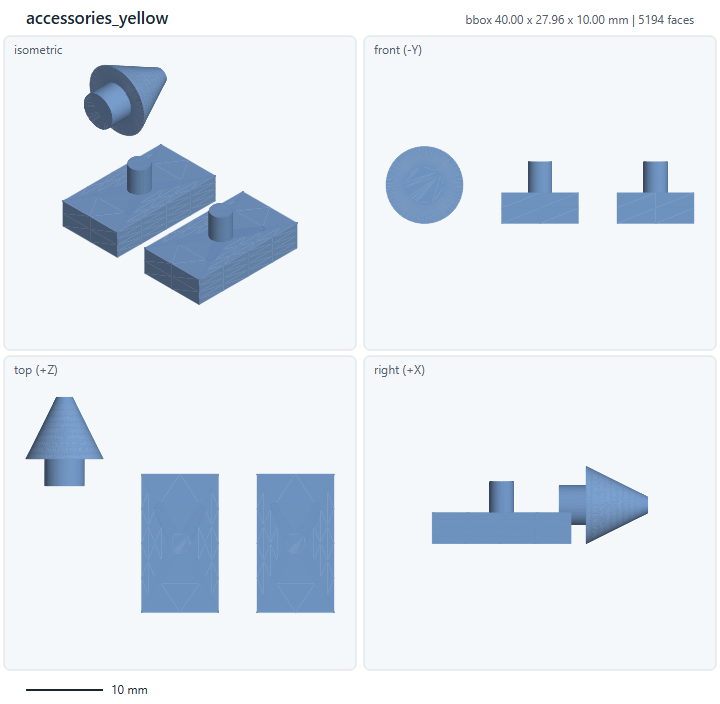

body_black | STL: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tux-penguin\outputs\tux_penguin\body_black.stl | slicer: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tux-penguin\outputs\tux_penguin\slicer\body_black\plate_1.gcode
belly_white | STL: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tux-penguin\outputs\tux_penguin\belly_white.stl | slicer: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tux-penguin\outputs\tux_penguin\slicer\belly_white\plate_1.gcode
accessories_yellow | STL: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tux-penguin\outputs\tux_penguin\accessories_yellow.stl | slicer: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tux-penguin\outputs\tux_penguin\slicer\accessories_yellow\plate_1.gcode


In [5]:
report_path, report = run(MODEL, PROFILE, OUT, enable_raster=True)
show_run(report)
for part in report['parts']:
    print(part['name'], '| STL:', part['artifacts']['stl'],
          '| slicer:', part['slicer'].get('gcode', part['slicer']['status']))